In [ ]:
import numpy as np
from sim_library.simulation import simulate_alg_cooling, p_shift_random_walk
from sim_library.sequences import RR3_gate, exchange10_gate, PulseSequence, DownPulse,  gen_MDFEup_seq, FreeEvolution
from sim_library.data_io import load_p_dists
from sim_library.plotting import plot_coolingcycles_23, plot_coolingcycles_22, plot_coolingcycles_21, fit_gaussian
from sim_library.constants import k_eff, dR, m, omega_eg, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path

### Adjusted MDFE 500kHz (fig 12 in 2nd year report)

In [3]:
path = Path("data/algorithmic cooling/2026-05-15_algcooling_f3_16cycles_15muK_50000atoms_5e+05Hz_1.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

# Convert to units of hbark
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

# Finds highest/lowest momentum values across entire data
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

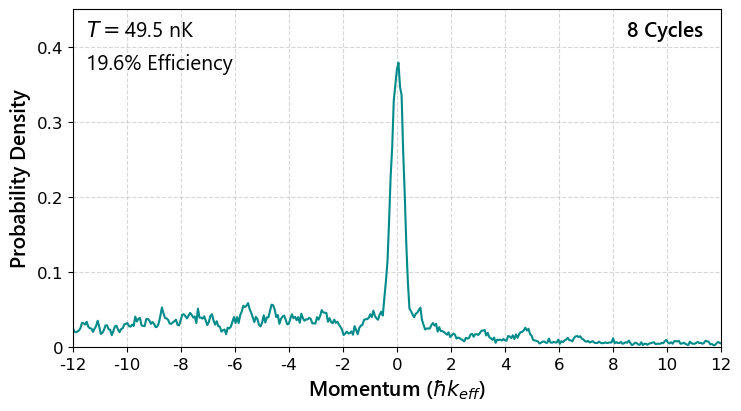

In [4]:
# plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(1,1, figsize=(7.3, 4), layout= 'constrained')

counts, bin_edges = np.histogram(moms_list[-17], weights=fracs_list[-17], bins = 2000, density=True, range=global_range)
bindiff = bin_edges[1]-bin_edges[0]
binmids = bin_edges[:-1] + (bindiff/2)
ax.plot(binmids, counts, linewidth=1.5, c = 'darkcyan')
ax.set_xticks(basis[0::2], basis[0::2], fontsize = 12)
ax.set_xlim(-12,12)

ax.set_ylim(0,0.45)
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4], [0, 0.1, 0.2, 0.3, 0.4], fontsize = 12)

ax.text(8.5,0.414,rf'{8} Cycles', fontname = 'Segoe UI', fontsize= 15, fontweight = 'semibold')
ax.text(-11.5,0.414,rf'$T=$49.5 nK', fontname = 'Segoe UI', fontsize= 15)
ax.text(-11.5,0.37,rf'19.6% Efficiency', fontname = 'Segoe UI', fontsize= 15)

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax.set_ylabel('Probability Density', fontname = 'Segoe UI', fontsize= 15, fontweight = 'semibold')
ax.set_xlabel(r'Momentum ($\hbar k_{eff}$)', fontname= 'Segoe UI', fontsize= 15, fontweight = 'semibold')

fig.savefig('plots/histograms/adjustedMDFE_500khz_flatbeamprof_confrev.pdf', format='pdf', bbox_inches='tight')

### Algorithmic cooling flat distribution (fig 9 in 2nd year report)

In [ ]:
path = Path("data/algorithmic cooling/flat/2026-04-13_algcooling_f3_16cycles_1000000atoms_5e+10Hz.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

# Convert to units of hbark
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

# Finds highest/lowest momentum values across entire data
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

In [ ]:
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(1,1, figsize=(7.3, 4), layout= 'constrained')

counts, bin_edges = np.histogram(moms_list[-17], weights=fracs_list[-17], bins = 5000, density=True, range=global_range)
bindiff = bin_edges[1]-bin_edges[0]
binmids = bin_edges[:-1] + (bindiff/2)
ax.plot(binmids, counts, linewidth=1.5, c = 'rebeccapurple')
ax.set_xticks(basis[0::2], basis[0::2], fontsize = 12)
ax.set_xlim(-12,12)

ax.set_ylim(0,0.1799)
ax.set_yticks([0.0, 0.03, 0.06, 0.09, 0.12, 0.15], [0.0, 0.03, 0.06, 0.09, 0.12, 0.15], fontsize = 12)

ax.text(8.8,0.166,rf'{8} Cycles', fontname = 'Segoe UI', fontsize= 15, fontweight = 'semibold')

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax.set_ylabel('Probability Density', fontname = 'Segoe UI', fontsize= 15, fontweight = 'semibold')
ax.set_xlabel(r'Momentum ($\hbar k_{eff}$)', fontname= 'Segoe UI', fontsize= 15, fontweight = 'semibold')

# fig.savefig('plots/posters/histograms/flat_1milatoms_500kHz_15muK_16cycles.pdf', format='pdf', bbox_inches='tight')

### BQIT Poster plot (not sure what original data file was)

In [ ]:
path = Path("_.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

# Convert to units of hbark
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

# Finds highest/lowest momentum values across entire data
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

In [ ]:
cycles_list = np.array([0,4,8,16])
index_list = np.array([0,8,16,32])
bins_list = np.full(4, 5000)
bins_list[0] = 5000

plt.rcParams['font.family'] = 'sans-serif'
fig, axes = plt.subplots(2,2, figsize=(8.5, 5.5), layout= 'constrained')
axes = axes.flatten()

top = 0.35

# global_min = min([min(m) for m in moms_list])
# global_max = max([max(m) for m in moms_list])
# global_range = (global_min, global_max)

for i in range(0,4):
        # counts, _, _ = axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i]], bins = bins_list[i], histtype='step', density=True, 
        #                             range=global_range,
        #                              linewidth = 1.5)
        counts, bin_edges = np.histogram(moms_list[index_list[i]], weights=fracs_list[index_list[i]], bins = bins_list[i], density=True, range=global_range)
        bindiff = bin_edges[1]-bin_edges[0]
        binmids = bin_edges[:-1] + (bindiff/2)
        axes[i].plot(binmids, counts, linewidth = 1.5, c = 'royalblue')
        axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 10)
        axes[i].set_xlim(-14,14)
        axes[i].grid(True, linestyle='--', alpha=0.5, zorder=0)

yticks = np.arange(int(top*20)+1)*0.05

for i in range(0,4):
    axes[i].set_ylim(0,top)
    axes[i].set_yticks(yticks, [0.0, '', 0.1, '', 0.2, '', 0.3, ''], fontsize = 10)
    if i != 3:
        axes[i].text((len(basis)*0.74)+basis[0],top*0.9,rf'{cycles_list[i]} Cycles', fontname = 'Segoe UI', fontsize= 13, fontweight = 'semibold')

axes[3].text((len(basis)*0.72)+basis[0],top*0.9,rf'16 Cycles', fontname = 'Segoe UI', fontsize= 13, fontweight = 'semibold')

axes[0].text((len(basis)*0.08)+basis[0],top*0.91,rf'$T={15:.0f}\mu K$', fontname = 'Segoe UI',fontsize= 11, fontweight = 'semibold')
axes[1].text((len(basis)*0.08)+basis[0],top*0.91,rf'$T={212:.0f}nK$',fontname = 'Segoe UI', fontsize= 11, fontweight = 'semibold')
axes[2].text((len(basis)*0.08)+basis[0],top*0.91,rf'$T={107:.0f}nK$', fontname = 'Segoe UI', fontsize= 11, fontweight = 'semibold')
axes[3].text((len(basis)*0.08)+basis[0],top*0.91,rf'$T={54.9:.1f}nK$', fontname = 'Segoe UI', fontsize= 11, fontweight = 'semibold')

axes[1].text((len(basis)*0.08)+basis[0],top*0.82,rf'25% Efficiency',fontname = 'Segoe UI', fontsize= 12)
axes[2].text((len(basis)*0.08)+basis[0],top*0.82,rf'21% Efficiency',fontname = 'Segoe UI', fontsize= 12)
axes[3].text((len(basis)*0.08)+basis[0],top*0.82,rf'16% Efficiency',fontname = 'Segoe UI', fontsize= 12)

supy = fig.supylabel('Probability Density', fontname = 'Segoe UI', fontsize= 18, fontweight = 'semibold', x=-0.04, y=0.53)
supx = fig.supxlabel(r'Momentum ($\hbar k_{eff}$)', fontname= 'Segoe UI', fontsize= 18, fontweight = 'semibold', x=0.51, y=-0.07)


fig.savefig('plots/posters/histograms/adjustedRR3_1milatoms_500kHz_15muK_16cycles.svg', format='svg', bbox_inches='tight', bbox_extra_artists=(supx, supy))

### Optical pumping p spread (fig 10 in 2nd year report)

In [ ]:
# random walks
ground_state_ratio = 0.528

N = 100000000
p_dist = np.zeros(N)
n_dist = np.zeros(N)

for i in range(N):
    p, n = p_shift_random_walk(ground_state_ratio=ground_state_ratio)
    p_dist[i] = p
    n_dist[i] = n

n_photons, n_photons_counts = np.unique(n_dist, return_counts=True)
p_dist = p_dist/2

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), layout= 'constrained')

ax1.hist(x= p_dist, bins = 700, density=True, color = 'skyblue')
ax1.hist(x= p_dist, bins = 700, density=True, color = 'black', histtype='step', linewidth=0.5)
# ax2.bar(x= n_photons, height=n_photons_counts)

ax1.set_title(rf"$F'=2$ Decay Path, $\Delta p_{{rms}} =${np.sqrt(np.mean(p_dist**2)):.3g}")
ax1.set_xlabel(r'$\Delta p$ ($\hbar k_{eff}$)', fontsize = 12)
ax1.set_ylabel('Probability Density', fontsize = 12)
ax1.set_xlim(-4,4)
ax1.set_ylim(0,0.55)

# ax2.set_title(rf'Distribution of $n$ photons scattered, $\langle n\rangle =${np.mean(n_dist):.3g}')
# ax2.set_xlabel(r'$n$')
# ax2.set_ylabel(r'Frequency')
# ax2.set_xlim(0,np.max(n_dist))
# ax2.set_xticks(np.arange(n_photons[0],n_photons[-1]+1))
# random walks
ground_state_ratio = 0.831

p_dist = np.zeros(N)
n_dist = np.zeros(N)

for i in range(N):
    p, n = p_shift_random_walk(ground_state_ratio=ground_state_ratio)
    p_dist[i] = p
    n_dist[i] = n

n_photons, n_photons_counts = np.unique(n_dist, return_counts=True)
p_dist = p_dist/2



ax2.hist(x= p_dist, bins = 700, density=True, color= 'seagreen')
ax2.hist(x= p_dist, bins = 700, density=True, color= 'black',linewidth = 0.5, histtype='step')
# ax2.bar(x= n_photons, height=n_photons_counts)

ax2.set_title(rf"$F'=3$ Decay Path, $\Delta p_{{rms}} =${np.sqrt(np.mean(p_dist**2)):.3g}")
ax2.set_xlabel(r'$\Delta p$ ($\hbar k_{eff}$)', fontsize = 12)
# ax2.set_ylabel('Probability Density')
ax2.set_ylim(0,0.55)
ax2.set_xlim(-4,4)



# plt.savefig(fname = 'plots/histograms/opticalpumping_confrev.png', dpi=1200, format='png', bbox_inches='tight')